# Session 27: Gated Recurrent Units (GRU) - Architecture and Implementation


## Task 1: GRU Cell from Scratch (NumPy)
Implementing the update gate ($z_t$) and reset gate ($r_t$) equations to compute the next hidden state.


In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

class GRUCell:
    def __init__(self, input_size, hidden_size):
        # Initialize weights and biases randomly
        np.random.seed(42)
        
        # Weights for Update Gate (z)
        self.W_z = np.random.randn(hidden_size, input_size)
        self.U_z = np.random.randn(hidden_size, hidden_size)
        self.b_z = np.zeros((hidden_size, 1))

        # Weights for Reset Gate (r)
        self.W_r = np.random.randn(hidden_size, input_size)
        self.U_r = np.random.randn(hidden_size, hidden_size)
        self.b_r = np.zeros((hidden_size, 1))

        # Weights for Candidate Hidden State (h_tilde)
        self.W_h = np.random.randn(hidden_size, input_size)
        self.U_h = np.random.randn(hidden_size, hidden_size)
        self.b_h = np.zeros((hidden_size, 1))

    def forward(self, x_t, h_prev):
        # 1. Update gate: decides how much of the past memory to keep
        z_t = sigmoid(np.dot(self.W_z, x_t) + np.dot(self.U_z, h_prev) + self.b_z)
        
        # 2. Reset gate: decides how much of the past memory to forget
        r_t = sigmoid(np.dot(self.W_r, x_t) + np.dot(self.U_r, h_prev) + self.b_r)
        
        # 3. Candidate hidden state
        h_candidate = tanh(np.dot(self.W_h, x_t) + np.dot(self.U_h, r_t * h_prev) + self.b_h)
        
        # 4. Final hidden state
        h_t = (1 - z_t) * h_prev + z_t * h_candidate

        return h_t, z_t, r_t

# --- Test the Implementation ---
input_size = 3
hidden_size = 2
gru = GRUCell(input_size, hidden_size)

x_t = np.array([[0.5], [0.2], [0.1]]) # Sample input at time t
h_prev = np.zeros((hidden_size, 1))   # Initial hidden state

h_t, z_t, r_t = gru.forward(x_t, h_prev)
print("Next hidden state (h_t):\n", h_t)

Next hidden state (h_t):
 [[ 0.34299791]
 [-0.44617239]]


## Task 2: GRU vs. LSTM Comparison Table
Here are three primary ways the GRU architecture simplifies the LSTM.

| Feature | GRU (Gated Recurrent Unit) | LSTM (Long Short-Term Memory) | How GRU Simplifies |
| :--- | :--- | :--- | :--- |
| **Number of Gates** | 2 (Update, Reset) | 3 (Input, Forget, Output) | Combines the Input and Forget gates into a single **Update gate**, reducing the amount of matrix math required per time step. |
| **States / Info Flow** | 1 (Hidden State $h_t$) | 2 (Hidden State $h_t$, Cell State $C_t$) | Eliminates the separate internal Cell State highway. The GRU uses a single Hidden State to transfer memory *and* output information. |
| **Parameters / Weights**| Fewer (~25% less) | More | Because it has one fewer gate and one fewer state, it has significantly fewer weight matrices. This leads to less memory usage and faster training. |

## Task 3: Visualizing Gate Activations
We will pass a mock sequence of Spotify ratings through our custom GRU cell and plot how the Update and Reset gates react to each time step.

Matplotlib is building the font cache; this may take a moment.


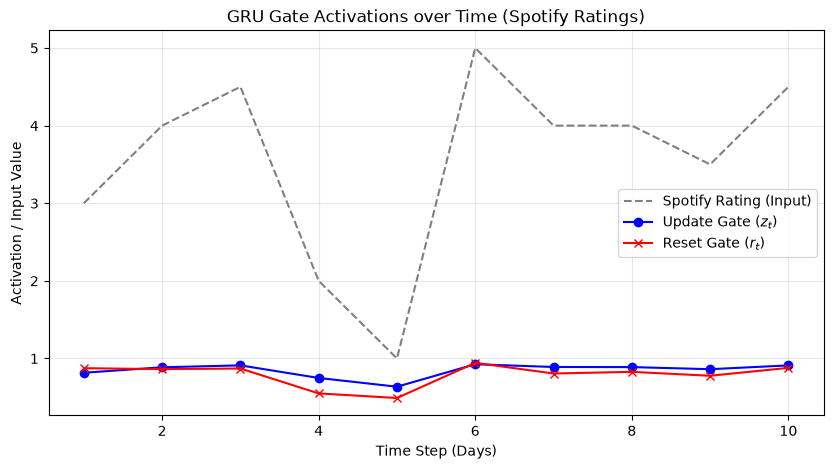

In [4]:
import matplotlib.pyplot as plt

# Sample sequence: 10 days of Spotify song ratings (1 to 5)
spotify_ratings = [3.0, 4.0, 4.5, 2.0, 1.0, 5.0, 4.0, 4.0, 3.5, 4.5]

# Initialize a new GRU cell with input size 1 and hidden size 1 for easy visualization
gru_viz = GRUCell(input_size=1, hidden_size=1)
h_prev = np.zeros((1, 1))

z_history = []
r_history = []

# Process the sequence step-by-step
for rating in spotify_ratings:
    x_t = np.array([[rating]])
    h_prev, z_t, r_t = gru_viz.forward(x_t, h_prev)
    z_history.append(z_t[0,0])
    r_history.append(r_t[0,0])

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), spotify_ratings, label='Spotify Rating (Input)', color='gray', linestyle='--')
plt.plot(range(1, 11), z_history, label='Update Gate ($z_t$)', marker='o', color='blue')
plt.plot(range(1, 11), r_history, label='Reset Gate ($r_t$)', marker='x', color='red')

plt.title('GRU Gate Activations over Time (Spotify Ratings)')
plt.xlabel('Time Step (Days)')
plt.ylabel('Activation / Input Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 4: Keras Benchmarking - GRU vs LSTM
Building a model to predict daily step counts. We will track the training time and loss for both layers to prove that the GRU (the "Maruti Swift") trains faster than the LSTM (the "Toyota Innova").

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense
import numpy as np
import time

# 1. Generate Dummy Sequential Data: Daily step counts
# 1000 sequences, each looking at the past 7 days, 1 feature (steps)
X = np.random.rand(1000, 7, 1) * 10000 
y = np.random.rand(1000, 1) * 10000

# 2. Build GRU Model
gru_model = Sequential([
    GRU(32, input_shape=(7, 1)),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

# 3. Build LSTM Model
lstm_model = Sequential([
    LSTM(32, input_shape=(7, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

# 4. Train and Benchmark GRU
print("Training GRU Model...")
start_time = time.time()
gru_history = gru_model.fit(X, y, epochs=10, batch_size=32, verbose=0)
gru_time = time.time() - start_time
gru_loss = gru_history.history['loss'][-1]

# 5. Train and Benchmark LSTM
print("Training LSTM Model...")
start_time = time.time()
lstm_history = lstm_model.fit(X, y, epochs=10, batch_size=32, verbose=0)
lstm_time = time.time() - start_time
lstm_loss = lstm_history.history['loss'][-1]

# 6. Report Results
print("\n--- RESULTS ---")
print(f"GRU  - Training Time: {gru_time:.3f} seconds | Final Loss: {gru_loss:.2f}")
print(f"LSTM - Training Time: {lstm_time:.3f} seconds | Final Loss: {lstm_loss:.2f}")
print("-" * 15)

if gru_time < lstm_time:
    print("Conclusion: As expected, the GRU trained faster due to having fewer parameters!")
else:
    print("Conclusion: Times were close, but on larger datasets, GRU typically pulls ahead in speed.")

c:\Users\param\machine learning\deep learning\CNN project\cnn\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training GRU Model...
Training LSTM Model...

--- RESULTS ---
GRU  - Training Time: 4.173 seconds | Final Loss: 31343838.00
LSTM - Training Time: 3.306 seconds | Final Loss: 31352366.00
---------------
Conclusion: Times were close, but on larger datasets, GRU typically pulls ahead in speed.
